
# Online Learning Mini-Workbook

This short workbook accompanies the online-learning lecture. It focuses on three ideas from the lecture:

1. **Predict first, then update** using a simple online gradient descent example.
2. **Bandits and UCB** using the lecture's random/greedy/UCB comparison.
3. **Adaptation under drift** using constant versus decaying step sizes.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

# Lecture-style colours
TEAL = "#1F3A3D"
ORANGE = "#D9792B"
BLUE = "#2F6FB0"
RED = "#C43C39"
GREEN = "#3E7C59"
GREY = "#F3F4F6"
DARKGREY = "#4B5563"
PURPLE = "#7C4D9E"
LIGHTBLUE = "#DCEAF8"

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})



## 1. Predict first, then update

In online learning, every new observation is first a **test point**. The learner:

$$
\text{predicts} \;\longrightarrow\; \text{observes the outcome} \;\longrightarrow\; \text{updates}.
$$

A simple example is online estimation of a mean. At time $t$, the learner predicts $w_t$, observes $y_t$, and suffers squared loss

$$
\ell_t(w_t)=\frac12(y_t-w_t)^2.
$$

The gradient is

$$
\nabla \ell_t(w_t)=w_t-y_t,
$$

so online gradient descent gives

$$
w_{t+1}=w_t-\eta_t(w_t-y_t)=(1-\eta_t)w_t+\eta_t y_t.
$$

This is a running update which blends the old estimate with the new observation.


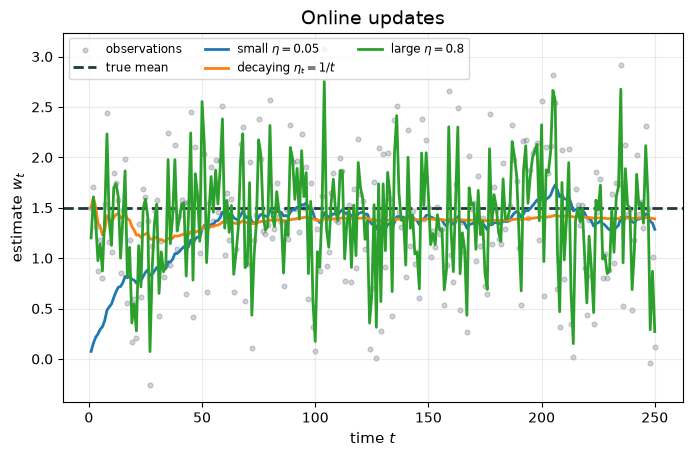

In [2]:

def online_mean_estimator(y, eta_schedule, w0=0.0):
    # Online mean estimator.
    # Returns predictions before the update, evaluation losses, and estimates after update.
    w = float(w0)
    predictions, losses, estimates_after_update = [], [], []
    for t, y_t in enumerate(y, start=1):
        # Predict before seeing y_t
        predictions.append(w)
        losses.append(0.5 * (y_t - w) ** 2)

        # Update after observing y_t
        eta_t = eta_schedule(t)
        w = (1 - eta_t) * w + eta_t * y_t
        estimates_after_update.append(w)

    return np.array(predictions), np.array(losses), np.array(estimates_after_update)

# Generate a stable stream with true mean 1.5
T = 250
true_mean = 1.5
y = true_mean + 0.7 * rng.normal(size=T)

schedules = {
    "small $\\eta=0.05$": lambda t: 0.05,
    "decaying $\\eta_t=1/t$": lambda t: 1.0 / t,
    "large $\\eta=0.8$": lambda t: 0.8,
}

fig, ax = plt.subplots()
ax.scatter(np.arange(1, T + 1), y, s=12, alpha=0.25, color=DARKGREY, label="observations")
ax.axhline(true_mean, color=TEAL, linestyle="--", linewidth=2, label="true mean")

for label, schedule in schedules.items():
    preds, losses, estimates = online_mean_estimator(y, schedule, w0=0.0)
    ax.plot(np.arange(1, T + 1), estimates, linewidth=2, label=label)

ax.set_title("Online updates")
ax.set_xlabel("time $t$")
ax.set_ylabel("estimate $w_t$")
ax.legend(frameon=True, ncol=3, fontsize="small")
plt.show()



## 2. Bandits: random exploration, greedy, and UCB

In a multi-armed bandit problem, the learner chooses one action, called an **arm**, and only observes the reward for that chosen arm.

We will use an easy five-arm Bernoulli bandit example with true means (equivalently, success probabilities):

$$
(\mu_1,\mu_2,\mu_3,\mu_4,\mu_5)=(0.10,0.45,0.15,0.70,0.25).
$$

Arm 4 is the best arm, but the learner does not know this initially.

We compare the three simple policies from the lecture:

- **Random exploration:** choose an arm uniformly at random.
- **Greedy:** pull each arm once, then choose the arm with largest sample mean.
- **UCB:** choose the arm with largest

$$
\widehat\mu_i(t-1)+\sqrt{\frac{2\log t}{N_i(t-1)}}.
$$


In [3]:

BANDIT_MEANS = np.array([0.10, 0.45, 0.15, 0.70, 0.25])
K = len(BANDIT_MEANS)
BEST_MEAN = BANDIT_MEANS.max()
BEST_ARM = int(np.argmax(BANDIT_MEANS))

print("Arm means:", BANDIT_MEANS)
print("Best arm:", BEST_ARM + 1, "with mean", BEST_MEAN)


def run_bandit_policy(means, policy="ucb", T=2000, seed=0):
    # Run one simulation of a Bernoulli bandit policy.
    # Regret is pseudo-regret: sum_t (mu_star - mu_{A_t}). (i.e., best mean less chosen arm's mean --- not the sample reward!)
    # Note: averaged over many independent runs, pseudo-regret and realized regret (relative to an oracle that knows the best arm)
    # converge to the same value (expected regret), since each reward has mean equal to its arm's true mean.
    rng = np.random.default_rng(seed)
    K = len(means)
    counts = np.zeros(K, dtype=int)
    sums = np.zeros(K, dtype=float)
    choices = np.zeros(T, dtype=int)
    rewards = np.zeros(T)
    cumulative_regret = np.zeros(T)
    regret_so_far = 0.0

    for t in range(1, T + 1):
        if policy == "random":
            arm = int(rng.integers(K))

        elif policy == "greedy":
            # Pull each arm once, then exploit the largest sample mean.
            if t <= K:
                arm = t - 1
            else:
                estimates = sums / np.maximum(counts, 1)
                arm = int(np.argmax(estimates))

        elif policy == "ucb":
            # Pull each arm once, then use sample mean + uncertainty bonus.
            if t <= K:
                arm = t - 1
            else:
                estimates = sums / counts
                bonus = np.sqrt(2 * np.log(t) / counts)
                arm = int(np.argmax(estimates + bonus))

        else:
            raise ValueError("policy must be 'random', 'greedy', or 'ucb'")

        reward = float(rng.random() < means[arm]) #random Bernoulli with given mean
        counts[arm] += 1
        sums[arm] += reward
        choices[t - 1] = arm
        rewards[t - 1] = reward

        regret_so_far += means.max() - means[arm]
        cumulative_regret[t - 1] = regret_so_far

    estimates = sums / np.maximum(counts, 1)
    return {
        "choices": choices,
        "rewards": rewards,
        "counts": counts,
        "estimates": estimates,
        "cumulative_regret": cumulative_regret,
    }


Arm means: [0.1  0.45 0.15 0.7  0.25]
Best arm: 4 with mean 0.7


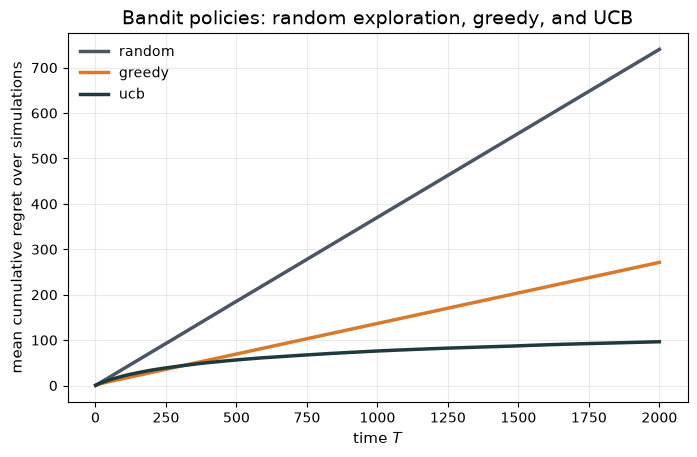

random | final regret:   740.3 | average arm pulls: [400.4 399.9 398.8 399.2 401.7]
greedy | final regret:   271.2 | average arm pulls: [ 213.1  301.5   48.7 1345.2   91.5]
   ucb | final regret:    96.4 | average arm pulls: [  31.5  133.4   37.5 1745.2   52.4]


In [4]:
# Average the regret curves over many independent simulation runs.
T = 2000
N_SIM = 200
policies = ["random", "greedy", "ucb"]

regret_curves = {policy: [] for policy in policies}
final_counts = {policy: [] for policy in policies}

for sim in range(N_SIM):
    for policy in policies:
        result = run_bandit_policy(BANDIT_MEANS, policy=policy, T=T, seed=10_000 + sim)
        regret_curves[policy].append(result["cumulative_regret"])
        final_counts[policy].append(result["counts"])

fig, ax = plt.subplots()
for policy, color in zip(policies, [DARKGREY, ORANGE, TEAL]):
    regrets = np.vstack(regret_curves[policy])
    mean_regret = regrets.mean(axis=0)
    ax.plot(np.arange(1, T + 1), mean_regret, label=policy, color=color, linewidth=2.5)

ax.set_title("Bandit policies: random exploration, greedy, and UCB")
ax.set_xlabel("time $T$")
ax.set_ylabel("mean cumulative regret over simulations")
ax.legend(frameon=False)
plt.show()

for policy in policies:
    regrets = np.vstack(regret_curves[policy])
    counts = np.vstack(final_counts[policy])
    print(f"{policy:>6s} | final regret: {regrets[:, -1].mean():7.1f} | average arm pulls: {counts.mean(axis=0).round(1)}")


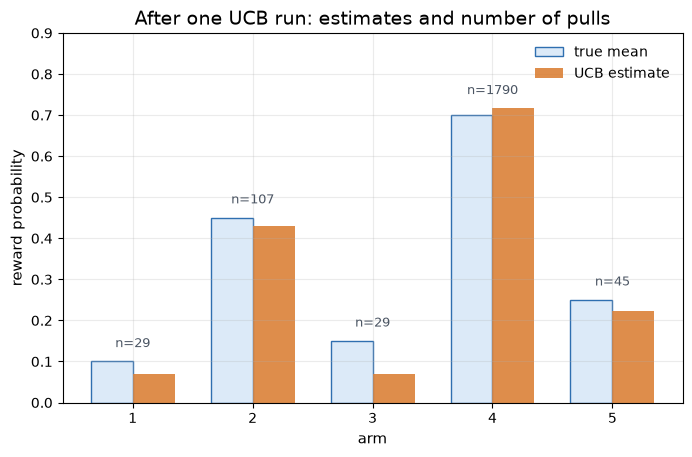

In [5]:

# Inspect one UCB run in more detail.
one_run = run_bandit_policy(BANDIT_MEANS, policy="ucb", T=2000, seed=123)
counts = one_run["counts"]
estimates = one_run["estimates"]

x = np.arange(1, K + 1)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - width/2, BANDIT_MEANS, width=width, label="true mean", color=LIGHTBLUE, edgecolor=BLUE)
ax.bar(x + width/2, estimates, width=width, label="UCB estimate", color=ORANGE, alpha=0.85)
for j, c in enumerate(counts, start=1):
    ax.text(j, max(BANDIT_MEANS[j-1], estimates[j-1]) + 0.035, f"n={c}", ha="center", fontsize=9, color=DARKGREY)
ax.set_xticks(x)
ax.set_xlabel("arm")
ax.set_ylabel("reward probability")
ax.set_ylim(0, 0.9)
ax.set_title("After one UCB run: estimates and number of pulls")
ax.legend(frameon=False)
plt.show()



## 3. Adaptation when the environment changes

Online learning is useful because models can update over time. But there is a tradeoff:

- An appropriately **decaying** step size converges nicely when the world is stable.
- A **constant** step size keeps adapting when the world changes.

Here the mean of the stream changes halfway through. This is a simple form of **concept drift**.


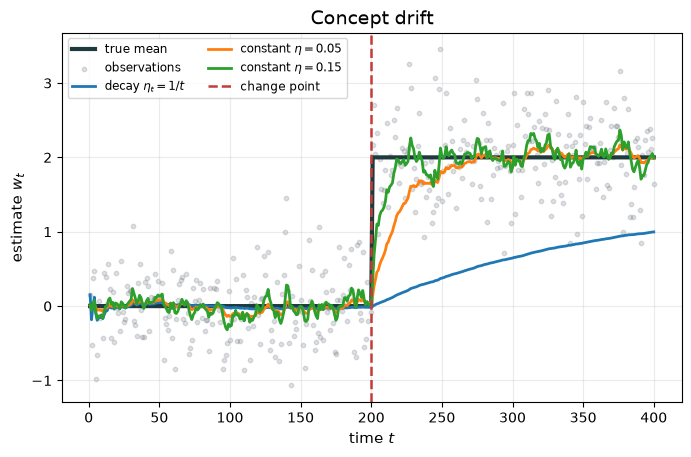

In [6]:

# A drifting stream: the mean changes at t = 200.
rng = np.random.default_rng(42)
T = 400
change_point = 200
mean_before = 0.0
mean_after = 2.0
noise_sd = 0.5

true_means = np.r_[np.full(change_point, mean_before), np.full(T - change_point, mean_after)]
y_drift = true_means + noise_sd * rng.normal(size=T)

adaptive_schedules = {
    "decay $\\eta_t=1/t$": lambda t: 1.0 / t,
    "constant $\\eta=0.05$": lambda t: 0.05,
    "constant $\\eta=0.15$": lambda t: 0.15,
}

fig, ax = plt.subplots()
ax.plot(np.arange(1, T + 1), true_means, color=TEAL, linewidth=3, label="true mean")
ax.scatter(np.arange(1, T + 1), y_drift, s=10, alpha=0.18, color=DARKGREY, label="observations")

for label, schedule in adaptive_schedules.items():
    preds, losses, estimates = online_mean_estimator(y_drift, schedule, w0=0.0)
    ax.plot(np.arange(1, T + 1), estimates, linewidth=2, label=label)

ax.axvline(change_point, color=RED, linestyle="--", linewidth=1.8, label="change point")
ax.set_title("Concept drift")
ax.set_xlabel("time $t$")
ax.set_ylabel("estimate $w_t$")
ax.legend(frameon=True, ncol=2, fontsize="small")
plt.show()
